# Week 2: Explainable AI & Model Interpretation

<small>OPAN 6604. Dataset: `Players.csv` (2,420 outfield players, top-7 European leagues, 2024/25). Target: post-season market value in euros.</small>

<small>Steps 1–5 reuse the baseline Random Forest model from the W1 hyperparameter tuning notebook so we have something to explain. The explainability section is the focus: global methods (Permutation Importance, Partial Dependence Plots) followed by local methods (ICE, SHAP, LIME).</small>

<small>**Note on scale:** the target is `log1p`-transformed before training, so model outputs (PDP and ICE curves, SHAP values, LIME weights) are on the log scale. The pattern of feature effects is unchanged - only the units differ.</small>

### Step 0: Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing + model
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# Train/test split + evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Explainability (model-agnostic, sklearn)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

RANDOM_STATE = 6604

### Step 1: Load data

In [3]:
# Same Players.csv as W1
df = pd.read_csv("Players.csv")

print("Shape:", df.shape)
df.head()

Shape: (2420, 16)


,player_id,name,age_at_season_end,country_of_citizenship,sub_position,foot,height_in_cm,league,matches,minutes,goals,assists,yellow_cards,red_cards,market_value_eur_post_season,transfermarkt_url
0,937958,Lamine Yamal,17.965777,Spain,Right Winger,left,180.0,La Liga,35,2864,9,15,3,0,200000000,https://www.transfermarkt.com/player/profil/sp...
1,342229,Kylian Mbappé,26.527036,France,Centre-Forward,right,180.0,La Liga,34,2917,31,3,3,1,180000000,https://www.transfermarkt.com/player/profil/sp...
2,418560,Erling Haaland,24.941821,Other,Centre-Forward,left,195.0,Premier League,31,2743,22,3,2,0,180000000,https://www.transfermarkt.com/player/profil/sp...
3,581678,Jude Bellingham,22.004107,England,Attacking Midfield,right,186.0,La Liga,31,2493,9,9,5,1,180000000,https://www.transfermarkt.com/player/profil/sp...
4,371998,Vinicius Junior,24.966461,Brazil,Left Winger,right,176.0,La Liga,30,2258,11,10,8,1,170000000,https://www.transfermarkt.com/player/profil/sp...


### Step 2: Target distribution

<small>Market values are right-skewed. Model `log1p(market_value)` and back-transform for reporting.</small>

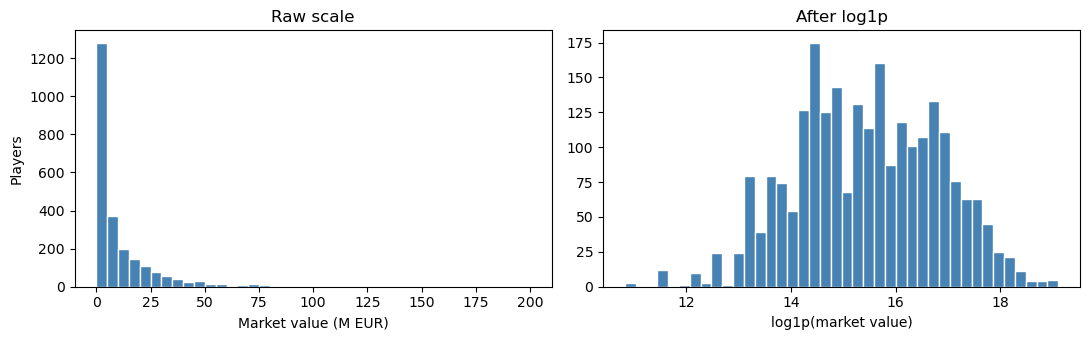

In [4]:
TARGET = "market_value_eur_post_season"

# Left: raw target (millions). Right: log1p transform.
# log1p is log(1 + x), which handles values near zero without exploding.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df[TARGET] / 1e6, bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Market value (M EUR)")
axes[0].set_ylabel("Players")
axes[0].set_title("Raw scale")

axes[1].hist(np.log1p(df[TARGET]), bins=40, color="steelblue", edgecolor="white")
axes[1].set_xlabel("log1p(market value)")
axes[1].set_title("After log1p")
plt.tight_layout()
plt.show()

### Step 3: Train/test split

In [5]:
# Identifiers are not useful as predictors. club_2024_25 stays as a feature.
drop_cols = [
    "player_id", "name", "transfermarkt_url",
]

X = df.drop(columns=drop_cols + [TARGET])
y = np.log1p(df[TARGET])  # train on log scale, back-transform for reporting

# Hold out 25% for the final test. Same seed = same split every run.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (1815, 12)  X_test: (605, 12)


### Step 4: Preprocessing pipeline

<small>Impute missing values (median for numerics, most-frequent for categoricals), then one-hot encode categoricals. Wrapped in a `Pipeline` so the imputer and encoder only see each CV fold's training portion.</small>

In [6]:
# Trees don't need scaling, but they do need non-NaN inputs.
# Impute missing values inside the Pipeline so that
# the imputer is fit only on the training data of each CV fold preventing data leakage.
numeric_features = [
    "age_at_season_end", "height_in_cm",
    "matches", "minutes",
    "goals", "assists",
    "yellow_cards", "red_cards"
]

categorical_features = [
    "country_of_citizenship",
    "sub_position",
    "foot",
    "league"
]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # handle_unknown="ignore" -> unseen levels at test time become all-zero rows
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)

### Step 5: Baseline Random Forest model

<small>Random Forest with default hyperparameters, the same baseline used in the W1 tuning notebook. We need a trained model to apply explainability methods to.</small>

In [7]:
def report(name, model, X_tr, y_tr, X_te, y_te):
    """All metrics in euros (original scale).
    Train + test reported so the gap can be read as an overfit signal."""
    # Model predicts in log space (y was log1p-transformed). Back-transform to euros.
    pred_tr_eur = np.expm1(model.predict(X_tr))
    pred_te_eur = np.expm1(model.predict(X_te))
    y_tr_eur    = np.expm1(y_tr)
    y_te_eur    = np.expm1(y_te)

    return {
        "model":      name,
        "train_R2":   r2_score(y_tr_eur, pred_tr_eur),
        "test_R2":    r2_score(y_te_eur, pred_te_eur),
        "train_RMSE": np.sqrt(mean_squared_error(y_tr_eur, pred_tr_eur)),
        "test_RMSE":  np.sqrt(mean_squared_error(y_te_eur, pred_te_eur)),
        "train_MAE":  mean_absolute_error(y_tr_eur, pred_tr_eur),
        "test_MAE":   mean_absolute_error(y_te_eur, pred_te_eur),
    }


# Pipeline = preprocessing + model in one object, so CV cannot leak
rf_baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_baseline.fit(X_train, y_train)

# Print the RF defaults used for the baseline; these are the values tuning needs to beat.
defaults = rf_baseline.named_steps["model"].get_params()
print("RF defaults:")
for k in ["n_estimators", "max_depth", "max_features",
          "min_samples_leaf", "min_samples_split", "bootstrap", "criterion"]:
    print(f"  {k}: {defaults[k]}")

baseline_row = report("Baseline (defaults)", rf_baseline, X_train, y_train, X_test, y_test)
pd.DataFrame([baseline_row])

RF defaults:
  n_estimators: 100
  max_depth: None
  max_features: 1.0
  min_samples_leaf: 1
  min_samples_split: 2
  bootstrap: True
  criterion: squared_error


,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Baseline (defaults),0.84734,0.391733,7.621872e+06,1.181496e+07,3.032633e+06,6.149255e+06


---
## Part 1: Global Interpretation

<small>Global methods explain overall model behavior across all predictions. They answer: which features drive the model, and how do they affect predictions on average? Applied to a trained model during development and validation.</small>

### Permutation Feature Importance

<small>Measures how much each feature contributes to model performance by randomly shuffling one feature's values and observing how much performance drops. Higher drop = more important feature. Model-agnostic - works for any supervised model.</small>

In [ ]:
# Apply permutation importance to the trained pipeline using the test set.
# Using test data (vs training) checks whether feature importance generalizes to unseen data.
# Use n_repeats=5-10 for more stable estimates (slower).
result = permutation_importance(
    rf_baseline, X_test, y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature":    X_test.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
5,league,0.481274
0,age_at_season_end,0.378530
7,minutes,0.118965
9,assists,0.080980
8,goals,0.060007
2,sub_position,0.002915
3,foot,0.000169
11,red_cards,-0.000044
1,country_of_citizenship,-0.000976
10,yellow_cards,-0.002456


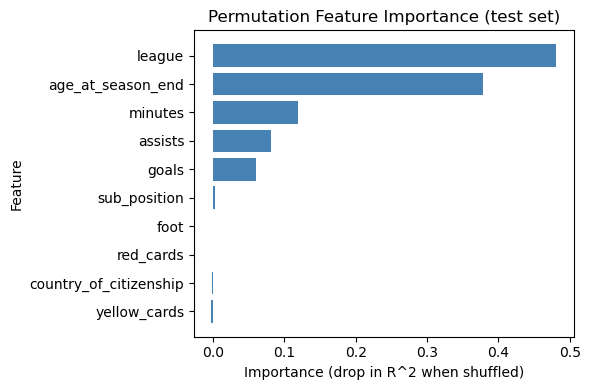

In [9]:
# Plot the top 10 most important features
plt.figure(figsize=(6, 4))
top10 = importance_df.head(10)
plt.barh(top10["feature"], top10["importance"], color="steelblue")
plt.xlabel("Importance (drop in R^2 when shuffled)")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (test set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Partial Dependence Plots (PDP)

<small>PDPs show the marginal effect of a feature on predictions, averaged over all other features. Reveals whether a feature's effect is linear, monotonic, or has thresholds/saturation. Plotting PDPs for the three most important features identified above.</small>

Top 3 features: ['league', 'age_at_season_end', 'minutes']


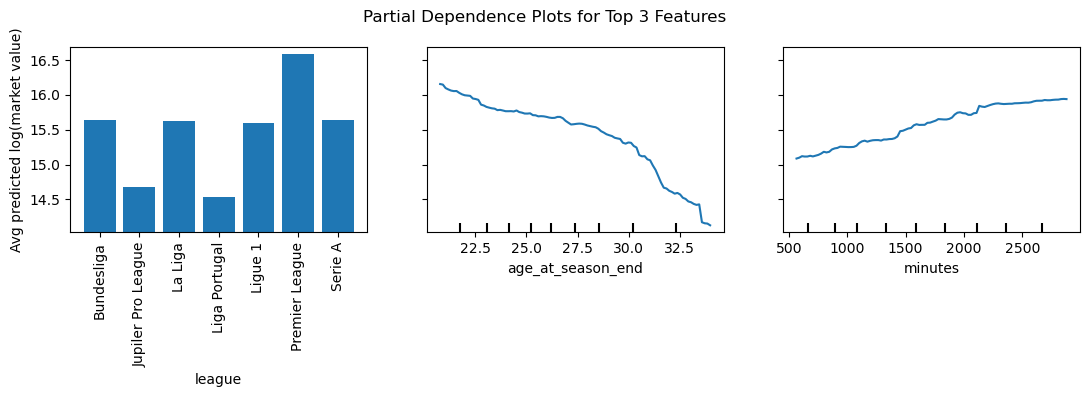

In [28]:
top_features = importance_df["feature"].head(3).tolist()
print("Top 3 features:", top_features)

# PDP queries model behavior (not performance), so training data is used.
fig, ax = plt.subplots(figsize=(11, 4))
display = PartialDependenceDisplay.from_estimator(
    rf_baseline,
    X_train,
    features=top_features,
    categorical_features=categorical_features,  # the list defined in Step 4
    ax=ax
)
display.axes_[0, 0].set_ylabel("Avg predicted log(market value)")
plt.suptitle("Partial Dependence Plots for Top 3 Features")
plt.tight_layout()
plt.show()

---
## Part 2: Local Interpretation

<small>Local methods explain individual predictions. They answer: why did the model make this specific prediction for this instance, and what would change the outcome? Applied in production for individual cases (e.g., explaining a single player's predicted value).</small>

### Individual Conditional Expectation (ICE)

<small>ICE plots show how each instance's prediction changes as a single feature varies. The PDP (yellow line) is the average of all blue ICE curves. Spread in the curves reveals heterogeneous effects that the PDP average would otherwise hide.</small>

ICE features: ['age_at_season_end', 'minutes']


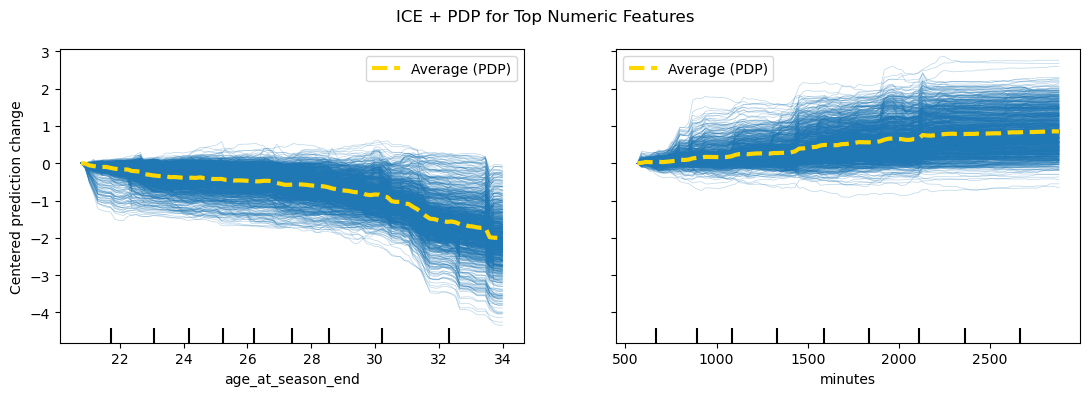

In [30]:
# ICE needs continuous features. Filter top_features to numeric only.
ice_features = [f for f in top_features if f in numeric_features]
print("ICE features:", ice_features)

# centered=True aligns all curves at zero so we can compare slopes rather than absolute levels.
# Without centered=True, y-axis would be the absolute predicted log(market value).
fig, ax = plt.subplots(figsize=(11, 4))
display = PartialDependenceDisplay.from_estimator(
    rf_baseline,
    X_train,
    features=ice_features,
    kind="both",          # "both" = ICE curves + PDP average
    centered=True,
    ax=ax,
    pd_line_kw={"color": "gold", "label": "Average (PDP)", "linewidth": 3}
)
display.axes_[0, 0].set_ylabel("Centered prediction change")
plt.suptitle("ICE + PDP for Top Numeric Features")
plt.tight_layout()
plt.show()

### SHAP (Shapley Additive Explanations)

<small>SHAP distributes a prediction's deviation from the baseline (average prediction) across features, based on Shapley values from cooperative game theory. The result decomposes any individual prediction into per-feature contributions that sum to the prediction.</small>

<small>Install once if needed: `!pip install shap`</small>

  0%|          | 0/1 [00:00<?, ?it/s]

  NOTE: The following SHAP values are on the log scale (given that target was log transformed earlier).
  NOTE: They could be exponentiated (exp(shap) to get multiplicative effects on the original scale.


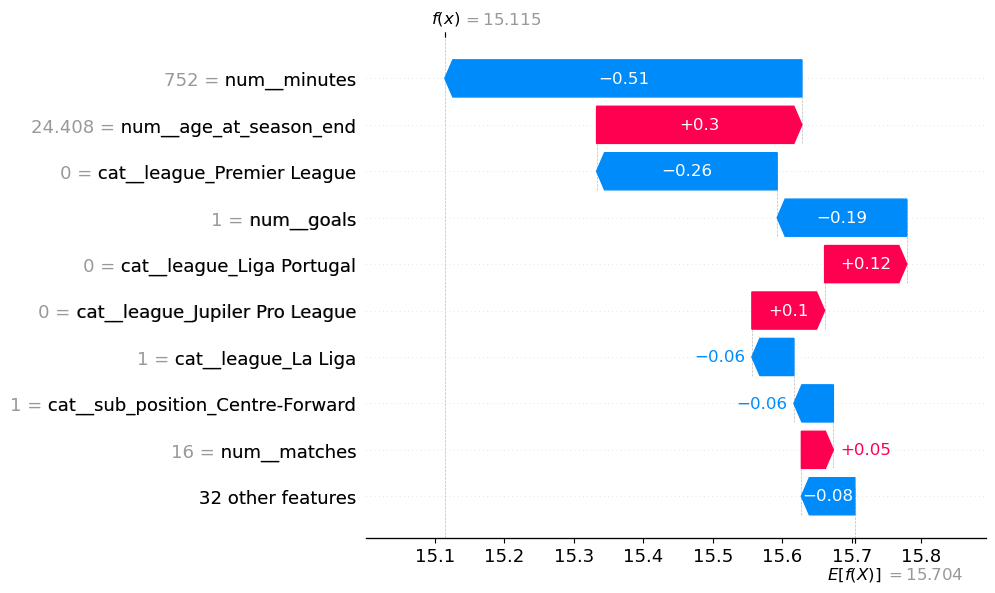

  Predicted market value: EUR 3,665,770


In [ ]:
import shap

# SHAP does not automatically see the transformations inside the sklearn Pipeline.
# The Random Forest was trained on the post-preprocessing numeric matrix,
# so we first extract the fitted preprocessor and transform X before explaining the model.
fitted_preprocessor = rf_baseline.named_steps["preprocess"]
rf_model            = rf_baseline.named_steps["model"]

X_train_tx = fitted_preprocessor.transform(X_train)
X_test_tx  = fitted_preprocessor.transform(X_test)
feature_names = fitted_preprocessor.get_feature_names_out()

# KernelExplainer is model-agnostic but slow.
# We can use a smaller background sample (100 rows for example) for faster approximations.
background = shap.sample(X_train_tx, 100, random_state=RANDOM_STATE)
explainer  = shap.KernelExplainer(rf_model.predict, background)

# Explain the FIRST player in the test set
instance = X_test_tx[0:1]
shap_values = explainer.shap_values(instance)

# SHAP waterfall plots expect the feature values for a single observation in a regular dense array format.
# If preprocessing creates a sparse matrix (common after one-hot encoding), we convert it to dense form before visualization.
instance_dense = instance.toarray()[0] if hasattr(instance, "toarray") else instance[0]

print(f"  NOTE: The following SHAP values are on the log scale (given that target was log transformed earlier).")
print(f"  NOTE: They could be exponentiated exp(shap) to get multiplicative effects on the original scale.")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=instance_dense,
        feature_names=list(feature_names)
    ),
    max_display=10
)

# Optional: Print the actual predicted value for the instance
pred_value = np.expm1(rf_baseline.predict(X_test.iloc[[0]]))[0]
print(f"  Predicted market value: EUR {pred_value:,.0f}")

### LIME (Local Interpretable Model-agnostic Explanations)

<small>LIME explains a single prediction by fitting a simple interpretable model (linear regression) to the complex model's behavior in a small neighborhood around that instance. The resulting linear weights show which features push the prediction up or down locally.</small>

<small>Install once if needed: `!pip install lime`</small>

In [ ]:
import lime
import lime.lime_tabular

# LIME needs the same post-preprocessor numeric matrix as SHAP.
# Convert sparse output from OneHotEncoder to dense if needed.
X_train_tx_dense = X_train_tx.toarray() if hasattr(X_train_tx, "toarray") else X_train_tx
X_test_tx_dense  = X_test_tx.toarray()  if hasattr(X_test_tx, "toarray")  else X_test_tx

# random_state ensures reproducibility since LIME randomly perturbs data to build local explanations.
# mode="regression" for continuous targets, "classification" for categorical targets.
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_tx_dense,
    feature_names=list(feature_names),
    mode="regression",
    random_state=RANDOM_STATE,
)

# Explain the same first test player
explanation = lime_explainer.explain_instance(
    X_test_tx_dense[0],
    rf_model.predict,
    num_features=10
)

explanation.show_in_notebook(show_table=True)